In [57]:
import base64
import requests

In [58]:
api_key = "<openai-api-key>"

In [59]:
# Path to your image
image_path = '../assets/Bori.jpg'
#image_path = '../assets/bollywood.png'

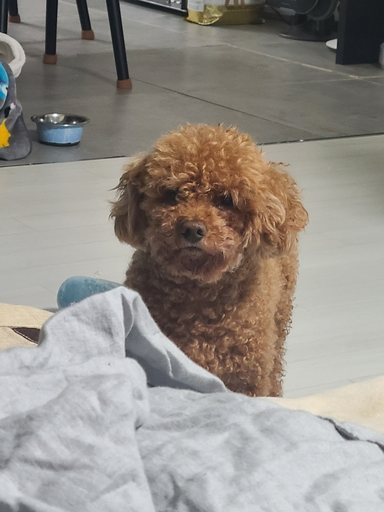

In [60]:
# Print the image (can delete this code in implementation)
from PIL import Image
image = Image.open(image_path)
image.thumbnail((512,512),Image.Resampling.LANCZOS)
init_state = dict(
    IMAGE=image.convert('RGB')
)
image

In [61]:
# Function to encode the image
def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

In [62]:
# List of specific commands that trigger image processing
photo_editing_commands = ["colorpop", "replace", "blur"]

In [63]:
# Function to check if the input is an image editing command
def is_photo_editing_command(user_input):
    return any(command in user_input.lower() for command in photo_editing_commands)

In [64]:
# Function to handle OpenAI text generation
def generate_text_response(user_input, image_path):
        
    # Getting the base64 string
    base64_image = encode_image(image_path)
    
    headers = {
        "Content-Type": "application/json",
        "Authorization": f"Bearer {api_key}"
    }
    
    payload = {
        "model": "gpt-4o-mini",
        "messages": [
            {
                "role": "system",
                "content": "You are a photo editor. You can do colorpop, replace, blur operataion for each object in the image."
            },
            {
                "role": "user",
                "content": [
                    {
                        "type": "text",
                        "text": user_msg
                    },
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": f"data:image/jpeg;base64,{base64_image}"
                        }
                    }
                ]
            }
        ],
        "max_tokens": 300
    }

    response = requests.post("https://api.openai.com/v1/chat/completions", headers=headers, json=payload)
    # Parse the JSON response
    response_json = response.json()
    
    # Print the response
    try:
        response = response_json['choices'][0]['message']['content']
        print(response)
    except KeyError as e:
        print("An error occurred:", e)
        print("Full response:", response_json)


In [66]:
# Hand over user input to image editing module
def handle_photo_editing(user_input, image_path):
    return 0

In [67]:
# Main function to handle user input
def process_user_input(user_input, image_path):
    if is_photo_editing_command(user_input):
        # Process the image based on user input
        edited_image = handle_photo_editing(user_input, image_path)
        # Save the output and return it
    else:
        # Generate and print the text response
        text_response = generate_text_response(user_input, image_path)
        print("Text Response:", text_response)

In [68]:
# Get instruction from user
user_msg = "List all the objects in the image."

In [69]:
process_user_input(user_msg, image_path)

The image contains the following objects:

1. A curly-haired dog.
2. A beige or light-colored blanket or fabric on the floor.
3. A blue dog bowl.
4. A metal dog bowl.
5. A couple of chairs or furniture legs (partially visible).
6. A blurred background showing additional objects (not distinctly identifiable). 

If you need more details or specific edits, let me know!
Text Response: None
